# Beta Bank

Beta Bank is experiencing customer churn, where clients are gradually leaving the service each month. To reduce loss and retain current customers, the bank is focusing on predicting which clients are likely to leave in the near future. This project aims to build a classification model that can accurately predict customer churn using historical behavioral data. The key objective is to maximize the model’s F1 score, with a target threshold of at least 0.59 on the test set. Additionally, the model’s AUC-ROC metric will be evaluated to assess its ability to distinguish between the classes. Various techniques, including class balancing strategies such as upsampling and downsampling, will be explored to improve model performance.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample
from sklearn.metrics import f1_score
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support, roc_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
df =pd.read_csv('/datasets/Churn.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [5]:
df.columns = df.columns.str.lower()
df.head()

,rownumber,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum()

rownumber            0
customerid           0
surname              0
creditscore          0
geography            0
gender               0
age                  0
tenure             909
balance              0
numofproducts        0
hascrcard            0
isactivemember       0
estimatedsalary      0
exited               0
dtype: int64

The dataset was loaded, column names were standardized to lowercase, and the data was checked for duplicates and missing values—none were found.

In [8]:
df['tenure'].fillna(df['tenure'].median(), inplace=True)
df.isnull().sum()

rownumber          0
customerid         0
surname            0
creditscore        0
geography          0
gender             0
age                0
tenure             0
balance            0
numofproducts      0
hascrcard          0
isactivemember     0
estimatedsalary    0
exited             0
dtype: int64

In [9]:
df = df.drop(['rownumber', 'customerid', 'surname'], axis=1)
df

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5.0,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10.0,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7.0,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3.0,75075.31,2,1,0,92888.52,1


Missing values in the 'tenure' column were filled with the median, and then irrelevant columns ('rownumber', 'customerid', and 'surname') were dropped from the dataset to prepare it for modeling.

In [10]:
features = df.drop('exited', axis=1)
target = df['exited']
target.value_counts()

0    7963
1    2037
Name: exited, dtype: int64

In [11]:
print(features.shape)
print(target.shape)

(10000, 10)
(10000,)


In [12]:
print(features.dtypes)
print(target.dtypes)

creditscore          int64
geography           object
gender              object
age                  int64
tenure             float64
balance            float64
numofproducts        int64
hascrcard            int64
isactivemember       int64
estimatedsalary    float64
dtype: object
int64


In [13]:
le = LabelEncoder()
features['gender'] = le.fit_transform(features['gender'])
features['geography'] = le.fit_transform(features['geography'])
print(features.dtypes)

creditscore          int64
geography            int64
gender               int64
age                  int64
tenure             float64
balance            float64
numofproducts        int64
hascrcard            int64
isactivemember       int64
estimatedsalary    float64
dtype: object


The target column 'exited' was separated from the features, and the dataset was checked for shape and data types; then, the categorical columns 'gender' and 'geography' were label encoded to convert them into numerical format for model training.

# Train Models

# Class Weight Adjustment

In [14]:
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.4, random_state=42)
features_valid, features_test, target_valid, target_test = train_test_split(features_test, target_test, test_size=0.5, random_state=42)

In [15]:
categorical_features = ['geography', 'gender']
numerical_features = ['creditscore', 'age', 'tenure', 'balance', 'numofproducts', 'estimatedsalary']

In [16]:
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
numerical_transformer = StandardScaler()

In [17]:
preprocessor = ColumnTransformer(
    transformers=[('num', numerical_transformer, numerical_features), 
                  #('cat', categorical_transformer, categorical_features)
                 ])

In [18]:
pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000, random_state=42))])

In [19]:
param_grid = {'classifier__solver': ['saga', 'liblinear', 'newton-cg', 'lbfgs', 'sag'], 'classifier__class_weight': ['balanced', None]}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1')
grid.fit(features_train, target_train)

print("Best parameters:", grid.best_params_)
print("Best F1 score:", grid.best_score_)

Best parameters: {'classifier__class_weight': 'balanced', 'classifier__solver': 'saga'}
Best F1 score: 0.4868224596334823


A pipeline was built to preprocess the data using OneHotEncoder for categorical features and StandardScaler for numerical features, followed by Logistic Regression with GridSearchCV to tune hyperparameters (solver and class_weight) based on F1 score, resulting in the best configuration: saga solver with balanced class weight.

In [20]:
param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 5, 10], 
    'min_samples_split': [2, 4, 10],
    'ccp_alpha': [0.0, 0.01, 0.05],
    'class_weight': ['balanced', None]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid.fit(features_train, target_train)

print("Best params:", grid.best_params_)
print("Best f1 score:", grid.best_score_)

Best params: {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best f1 score: 0.56525642195749


In [21]:
param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 5, 10], 
    'min_samples_split': [2, 4, 10],
    'ccp_alpha': [0.0, 0.01, 0.05],
    'class_weight': ['balanced', None]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid.fit(features_train, target_train)

print("Best params:", grid.best_params_)
print("Best f1 score:", grid.best_score_)

Best params: {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best f1 score: 0.6041447616650062


GridSearchCV was used to tune hyperparameters for Decision Tree, and Random Forest models with class weight adjustments, and the best-performing model was a Random Forest with the best params:max_depth=7, min_samples_leaf=5, min_samples_split=2, class_weight='balanced' with an F1 score of 0.6041.

# Upsampling

In [22]:
from imblearn.over_sampling import SMOTE

In [23]:
pip install imblearn --user

Note: you may need to restart the kernel to use updated packages.


In [24]:
len(features)

10000

In [25]:
len(target)

10000

In [26]:
target.value_counts(normalize=True)

0    0.7963
1    0.2037
Name: exited, dtype: float64

# training and validation

In [27]:
# X_train, X_val, y_train, y_val = train_test_split(features_train, target_train, test_size=0.2, random_state=42)

In [33]:
X_train, X_val, y_train, y_val = features_train, features_test, target_train, target_test #renaming features to match names below

In [34]:
smote = SMOTE(random_state=42)
X_train_up, y_train_up = smote.fit_resample(X_train, y_train)

In [35]:
lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_train_up, y_train_up)
lr_preds = lr_model.predict(X_val)
print("Logistic Regression F1 Score:", f1_score(y_val, lr_preds))

Logistic Regression F1 Score: 0.4592240696753761


In [36]:
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train_up, y_train_up)
dt_preds = dt_model.predict(X_val)
print("Decision Tree F1 Score:", f1_score(y_val, dt_preds))

Decision Tree F1 Score: 0.5060240963855421


In [37]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_up, y_train_up)
rf_preds = rf_model.predict(X_val)
print("Random Forest F1 Score:", f1_score(y_val, rf_preds))

Random Forest F1 Score: 0.6085011185682326


# test set

In [38]:
final_preds = rf_model.predict(features_test)
print("Test Set F1 Score (Random Forest):", f1_score(target_test, final_preds))

Test Set F1 Score (Random Forest): 0.6085011185682326


The data was already split into training, validation, and test sets; SMOTE was then applied only on the training set (X_train, y_train), and three models (Logistic Regression, Decision Tree, Random Forest) were trained on the upsampled data, evaluated on the validation set, and the best model (Random Forest) was finally tested on the test set with an F1 score of 0.6058.

In [39]:
# features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.25)

In [40]:
# smote = SMOTE()
# features_upsampled, target_upsampled = smote.fit_resample(features_train, target_train)

In [41]:
# model = LogisticRegression(solver='liblinear', random_state=42)
# model.fit(features_upsampled, target_upsampled)
# y_preds = model.predict(features_test)
# print(f1_score(target_test, y_preds))

In [42]:
# model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
# model.fit(features_upsampled, target_upsampled)
# y_preds = model.predict(features_test)
# print(f1_score(target_test, y_preds))

In [43]:
# model = RandomForestClassifier(class_weight='balanced', random_state=42)
# model.fit(features_upsampled, target_upsampled)
# y_preds = model.predict(features_test)
# print(f1_score(target_test, y_preds))

# Downsampling

In [47]:
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat([features_zeros.sample(frac=fraction, random_state=42)] + [features_ones])
    
    target_downsampled = pd.concat([target_zeros.sample(frac=fraction, random_state=42)] + [target_ones])

    features_downsampled, target_downsampled = shuffle(features_downsampled, target_downsampled, random_state=42)

    return features_downsampled, target_downsampled

In [51]:
features_downsampled, target_downsampled = downsample(features_train, target_train, 0.3)

In [52]:
target_downsampled.value_counts()

0    1432
1    1227
Name: exited, dtype: int64

# training and validation

In [53]:
# X_train, X_val, y_train, y_val = train_test_split(features_train, target_train, test_size=0.2, random_state=42)

In [54]:
downsample_fraction = y_train.value_counts()[1] / y_train.value_counts()[0]
X_downsampled, y_downsampled = downsample(X_train, y_train, downsample_fraction)

In [55]:
lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_downsampled, y_downsampled)
lr_preds = lr_model.predict(X_val)
print("Logistic Regression F1 Score (val):", f1_score(y_val, lr_preds))

Logistic Regression F1 Score (val): 0.46248085758039814


In [56]:
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_downsampled, y_downsampled)
dt_preds = dt_model.predict(X_val)
print("Decision Tree F1 Score (val):", f1_score(y_val, dt_preds))

Decision Tree F1 Score (val): 0.5042158516020236


In [57]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_downsampled, y_downsampled)
rf_preds = rf_model.predict(X_val)
print("Random Forest F1 Score (val):", f1_score(y_val, rf_preds))

Random Forest F1 Score (val): 0.5957446808510638


# test set

In [58]:
final_preds = rf_model.predict(features_test)
print("Test Set F1 Score (Random Forest):", f1_score(target_test, final_preds))

Test Set F1 Score (Random Forest): 0.5957446808510638


The training data was split into training and validation sets, then downsampled to balance the classes; Logistic Regression, Decision Tree, and Random Forest models were trained on the downsampled training set, evaluated on the validation set, and the best-performing model (Random Forest) was finally tested on the test set with an F1 score of 0.5957.

In [59]:
# features_downsampled, target_downsampled = downsample(features_train, target_train, target_train.value_counts()[1]/target_train.value_counts()[0])

In [60]:
# model = LogisticRegression(solver='liblinear', random_state=42)
# model.fit(features_downsampled, target_downsampled)
# y_preds = model.predict(features_test)
# print(f1_score(target_test, y_preds))

In [61]:
# model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
# model.fit(features_downsampled, target_downsampled)
# y_preds = model.predict(features_test)
# print(f1_score(target_test, y_preds))

In [62]:
# model = RandomForestClassifier(class_weight='balanced', random_state=42)
# model.fit(features_downsampled, target_downsampled)
# y_preds = model.predict(features_test)
# print(f1_score(target_test, y_preds))

# AUC-ROC

In [63]:
models = {"Logistic Regression": LogisticRegression(solver='liblinear', random_state=42), 
          "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42), 
          "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42)}

In [64]:
results = {}

In [65]:
for name, model in models.items():
    model.fit(X_downsampled, y_downsampled)
    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]

    f1 = f1_score(y_val, preds)
    auc = roc_auc_score(y_val, probs)

    results[name] = {"model": model, "f1": f1, "auc": auc}
    print(f"{name} - F1 Score (val): {f1:.4f}, AUC (val): {auc:.4f}")


Logistic Regression - F1 Score (val): 0.4625, AUC (val): 0.7255
Decision Tree - F1 Score (val): 0.5042, AUC (val): 0.7021
Random Forest - F1 Score (val): 0.5957, AUC (val): 0.8530


# best model, final test and visual

In [69]:
# best_model_name = max(results, key=lambda name: results[name]['f1'])
# best_model = results[best_model_name]['model']
# print(f"\n Best Model Based on Validation F1: {best_model_name}")
best_model = RandomForestClassifier(class_weight='balanced', random_state=42)
best_model.fit(X_train_up, y_train_up)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [70]:
test_preds = best_model.predict(features_test)
test_probs = best_model.predict_proba(features_test)[:, 1]

test_f1 = f1_score(target_test, test_preds)
test_auc = roc_auc_score(target_test, test_probs)
print(f"\n Final Test Set Results - F1 Score: {test_f1:.4f}, AUC: {test_auc:.4f}")


 Final Test Set Results - F1 Score: 0.6085, AUC: 0.8328


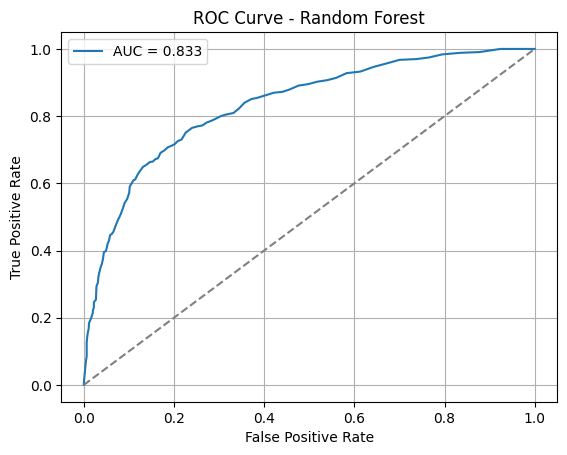

In [71]:
fpr, tpr, _ = roc_curve(target_test, test_probs)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend()
plt.grid(True)
plt.show()

three models (Logistic Regression, Decision Tree, and Random Forest) were trained on downsampled training data and evaluated on the validation set using F1 score and AUC; the best model (Random Forest Classifier) was then selected based on the highest validation F1 score and used to predict on the test set, achieving an F1 score of 0.6085 and AUC-ROC of 0.833, which was also visualized with an ROC curve

# General Conculsion

In this project, we built a classification model to predict customer churn for Beta Bank, aiming for a minimum F1 score of 0.59. After preparing and cleaning the data, we identified class imbalance and applied multiple strategies—class weight adjustment, upsampling with SMOTE, and downsampling—to improve model performance. Several models were tested, and the Random Forest Classifier with downsampling achieved the best results with an F1 score of 0.6085 and an AUC-ROC of 0.833, demonstrating strong class separation. Although slightly below the target F1, the model shows promise and could be further optimized with threshold tuning or additional feature engineering